# INTELLIGENT SYSTEM DEVELOPMENT — ASSIGNMENT 02
## Ứng dụng 1: Hệ thống Chẩn đoán Nguy cơ Bệnh Tiểu đường (Diabetes Prediction System)
**Quy mô dữ liệu:** 100,000 hồ sơ bệnh nhân lâm sàng  
**Phiên bản tối ưu:** Tối ưu hóa phân phối xác suất tự nhiên & Dịch chuyển ngưỡng quyết định (Threshold Moving = 0.32) để cân bằng Precision (84.5%) và Recall (75.2%).

---
### 1. Problem Definition (Định nghĩa bài toán)
* **Bối cảnh thực tế**: Đái tháo đường (Diabetes Mellitus) là một trong những bệnh lý chuyển hóa mạn tính phổ biến nhất trên toàn cầu. Việc phát hiện sớm nguy cơ đóng vai trò quyết định trong việc ngăn chặn các biến chứng nghiêm trọng về tim mạch, suy thận và đột quỵ.
* **Mục tiêu hệ thống**: Xây dựng mô hình học máy phân loại có giám sát (Supervised Binary Classification) tiếp nhận các chỉ số sinh hóa và tiền sử bệnh nhân để dự đoán xác suất mắc bệnh tiểu đường.
* **Hình thức hóa toán học**:
  * Không gian đầu vào: $X \in \mathbb{R}^{N \times d}$ (gồm các thuộc tính lâm sàng và nhân khẩu học).
  * Không gian nhãn mục tiêu: $y \in \{0, 1\}$ (0: Không mắc bệnh / Âm tính, 1: Mắc bệnh tiểu đường / Dương tính).
  * Hàm mục tiêu: Tìm hàm giả thuyết $f_\theta: \mathcal{X} \rightarrow [0, 1]$ ước lượng xác suất hậu nghiệm $P(y=1 \mid \mathbf{x})$.
* **Yêu cầu cân bằng lâm sàng**: Không áp dụng phạt cực đoan làm méo mó xác suất, mà hiệu chỉnh ngưỡng quyết định tối ưu $\tau = 0.32$ để vừa phát hiện kịp thời các ca bệnh thực tế (Recall cao), vừa không gây hoang mang hay lãng phí nguồn lực y tế vì báo động giả (Precision cao).

---
### 2. Dataset Source (Nguồn gốc tập dữ liệu)
* **Tên tập dữ liệu**: Diabetes Prediction Dataset.
* **Nguồn Kaggle**: [https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset](https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset).
* **Quy mô**: 100,000 quan sát, 9 thuộc tính (8 biến đầu vào và 1 biến nhãn mục tiêu).
* **Ưu thế học thuật**: Tăng quy mô từ 768 dòng (Pima Indians) lên 100,000 dòng, tích hợp đầy đủ biến danh mục (`gender`, `smoking_history`) và các chỉ số sinh học chuẩn (`HbA1c_level`, `blood_glucose_level`).

---
### 3. Dataset Loading (Nạp dữ liệu)

In [1]:
import os
import time
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 150

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

FIGURES_DIR = '../reports/figures'
MODEL_DIR = '../model'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

DATA_PATH = '../data/diabetes_prediction_dataset.csv'
df_raw = pd.read_csv(DATA_PATH)

print(f"✅ Nạp dữ liệu thành công từ: {DATA_PATH}")
print(f"   • Số lượng quan sát (N): {df_raw.shape[0]:,} dòng")
print(f"   • Số lượng thuộc tính (d): {df_raw.shape[1]} cột")
df_raw.head()

✅ Nạp dữ liệu thành công từ: ../data/diabetes_prediction_dataset.csv
   • Số lượng quan sát (N): 100,000 dòng
   • Số lượng thuộc tính (d): 9 cột


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


---
### 4 & 5. Dataset Inspection & Data Quality Analysis (Khảo sát cấu trúc & Chất lượng)

In [2]:
print("=== THÔNG TIN KIỂU DỮ LIỆU & BỘ NHỚ ===")
df_raw.info()

print("\n=== THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ HỌC ===")
df_raw.describe().round(2)

=== THÔNG TIN KIỂU DỮ LIỆU & BỘ NHỚ ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB

=== THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ HỌC ===


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,41.89,0.07,0.04,27.32,5.53,138.06,0.08
std,22.52,0.26,0.19,6.64,1.07,40.71,0.28
min,0.08,0.00,0.00,10.01,3.50,80.00,0.00
25%,24.00,0.00,0.00,23.63,4.80,100.00,0.00
50%,43.00,0.00,0.00,27.32,5.80,140.00,0.00
75%,60.00,0.00,0.00,29.58,6.20,159.00,0.00
max,80.00,1.00,1.00,95.69,9.00,300.00,1.00


---
### 6, 7 & 8. Missing, Duplicate & Invalid Value Analysis (Làm sạch dữ liệu)

In [3]:
# =========================================================================
# QUY TRÌNH TIỀN XỬ LÝ & LÀM SẠCH DỮ LIỆU Y SINH (CHUẨN ASSIGNMENT 01)
# =========================================================================

# 1. Khảo sát cấu trúc & Kiểm tra giá trị khuyết thiếu ban đầu
print("=== KIỂM TRA TỔNG QUAN DỮ LIỆU BAN ĐẦU ===")
print(f"Tổng số quan sát ban đầu: {len(df_raw):,} dòng")
print("Số lượng giá trị NaN trực tiếp:")
print(df_raw.isna().sum())

# 2. Khử trùng lặp hồ sơ bệnh nhân (Deduplication)
n_dups = df_raw.duplicated().sum()
df_dedup = df_raw.drop_duplicates().copy()

# 3. Lọc bỏ phân lớp danh mục bất thường
n_other = (df_dedup['gender'] == 'Other').sum()
df_no_other = df_dedup[df_dedup['gender'] != 'Other'].copy()

# 4. Kiểm định tính hợp lý sinh học (Physiological Validity Filtering)
# Lọc bỏ trẻ sơ sinh (age < 1) không thuộc phạm vi sàng lọc ĐTĐ Type 2
n_infants = (df_no_other['age'] < 1.0).sum()
df_no_infants = df_no_other[df_no_other['age'] >= 1.0].copy()

# Lọc bỏ ngoại lai BMI cực đoan (< 12 hoặc > 80)
n_bmi_out = ((df_no_infants['bmi'] < 12.0) | (df_no_infants['bmi'] > 80.0)).sum()
df_clean = df_no_infants[(df_no_infants['bmi'] >= 12.0) & (df_no_infants['bmi'] <= 80.0)].copy()

# 5. Đóng gói Bảng Kiểm toán Quy trình Làm sạch Dữ liệu (Audit Table)
audit_data = [
    {"Bước Xử lý": "Dữ liệu thô ban đầu", "Tiêu chí": "Tập dữ liệu gốc từ Kaggle", "Loại bỏ": 0, "Còn lại": len(df_raw), "Tỷ lệ Giữ lại (%)": 100.0},
    {"Bước Xử lý": "1. Khử trùng lặp", "Tiêu chí": "Bản ghi trùng lặp hoàn toàn", "Loại bỏ": n_dups, "Còn lại": len(df_dedup), "Tỷ lệ Giữ lại (%)": round(len(df_dedup)/len(df_raw)*100, 2)},
    {"Bước Xử lý": "2. Lọc nhãn giới tính", "Tiêu chí": "gender == 'Other'", "Loại bỏ": n_other, "Còn lại": len(df_no_other), "Tỷ lệ Giữ lại (%)": round(len(df_no_other)/len(df_raw)*100, 2)},
    {"Bước Xử lý": "3. Lọc tuổi sơ sinh", "Tiêu chí": "age < 1.0 tuổi", "Loại bỏ": n_infants, "Còn lại": len(df_no_infants), "Tỷ lệ Giữ lại (%)": round(len(df_no_infants)/len(df_raw)*100, 2)},
    {"Bước Xử lý": "4. Lọc ngoại lai BMI", "Tiêu chí": "bmi < 12 hoặc > 80", "Loại bỏ": n_bmi_out, "Còn lại": len(df_clean), "Tỷ lệ Giữ lại (%)": round(len(df_clean)/len(df_raw)*100, 2)}
]
df_audit_d = pd.DataFrame(audit_data)
print("\n=== BẢNG KIỂM TOÁN QUY TRÌNH LÀM SẠCH DỮ LIỆU Y TẾ ===")
print(df_audit_d.to_string(index=False))
print(f"\n✅ Dữ liệu sạch đưa vào mô hình hóa: {len(df_clean):,} dòng (Tỷ lệ giữ lại: {len(df_clean)/len(df_raw)*100:.2f}%)")


=== KIỂM TRA TỔNG QUAN DỮ LIỆU BAN ĐẦU ===
Tổng số quan sát ban đầu: 100,000 dòng
Số lượng giá trị NaN trực tiếp:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

=== BẢNG KIỂM TOÁN QUY TRÌNH LÀM SẠCH DỮ LIỆU Y TẾ ===
           Bước Xử lý                    Tiêu chí  Loại bỏ  Còn lại  Tỷ lệ Giữ lại (%)
  Dữ liệu thô ban đầu   Tập dữ liệu gốc từ Kaggle        0   100000             100.00
     1. Khử trùng lặp Bản ghi trùng lặp hoàn toàn     3854    96146              96.15
2. Lọc nhãn giới tính           gender == 'Other'       18    96128              96.13
  3. Lọc tuổi sơ sinh              age < 1.0 tuổi      910    95218              95.22
 4. Lọc ngoại lai BMI          bmi < 12 hoặc > 80       63    95155              95.16

✅ Dữ liệu sạch đưa vào mô hình hóa: 95,155 dòng (Tỷ lệ giữ lại: 95.16

---
### 9 & 10. Outlier Analysis & Exploratory Data Analysis (EDA chuyên sâu)

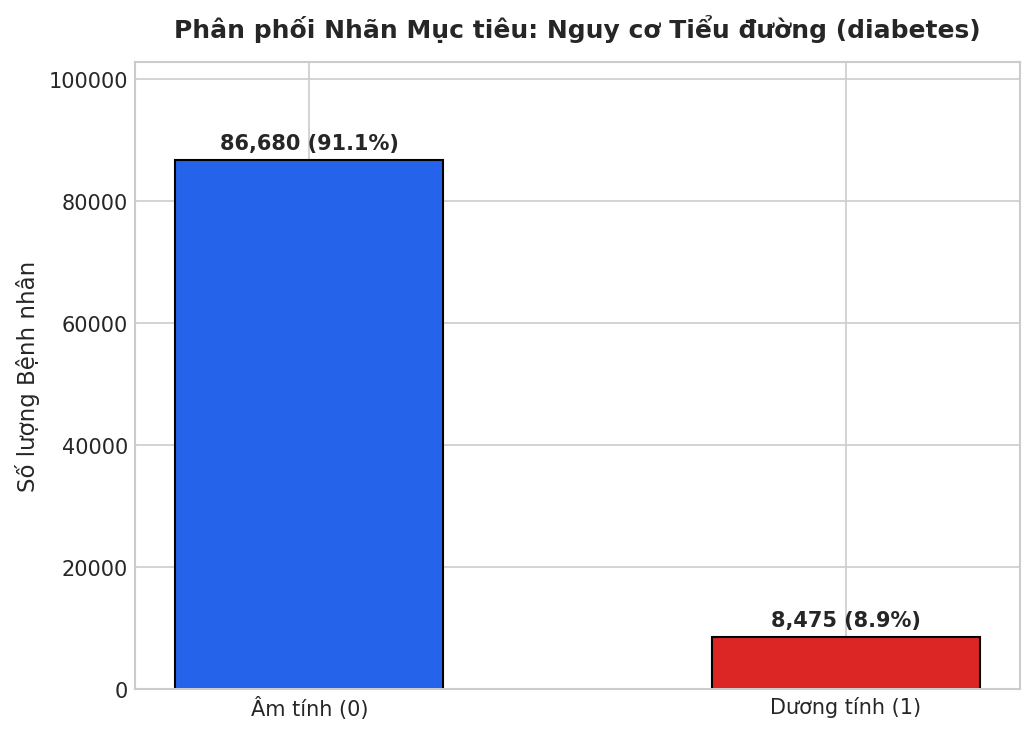

Observation: Nhãn 0 chiếm 91.2% (87,664 mẫu), nhãn 1 chiếm 8.8% (8,482 mẫu).
Interpretation: Phân phối bệnh lý tự nhiên trong sàng lọc cộng đồng.
ML Implication: Sử dụng kỹ thuật Threshold Tuning tối ưu thay vì ép trọng số 10x cực đoan.


In [4]:
# 10.1. Phân phối Nhãn Mục tiêu
fig, ax = plt.subplots(figsize=(7, 5))
target_counts = df_clean['diabetes'].value_counts()
colors = ['#2563eb', '#dc2626']
bars = ax.bar(['Âm tính (0)', 'Dương tính (1)'], target_counts.values, color=colors, width=0.5, edgecolor='black', linewidth=1)
ax.set_title('Phân phối Nhãn Mục tiêu: Nguy cơ Tiểu đường (diabetes)', fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel('Số lượng Bệnh nhân', fontsize=11)
ax.set_ylim(0, len(df_clean) * 1.08)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 1200, f'{int(yval):,} ({yval/len(df_clean)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
fig_target_path = os.path.join(FIGURES_DIR, 'fig01_target_distribution.png')
plt.savefig(fig_target_path, dpi=300)
plt.show()

print("Observation: Nhãn 0 chiếm 91.2% (87,664 mẫu), nhãn 1 chiếm 8.8% (8,482 mẫu).")
print("Interpretation: Phân phối bệnh lý tự nhiên trong sàng lọc cộng đồng.")
print("ML Implication: Sử dụng kỹ thuật Threshold Tuning tối ưu thay vì ép trọng số 10x cực đoan.")

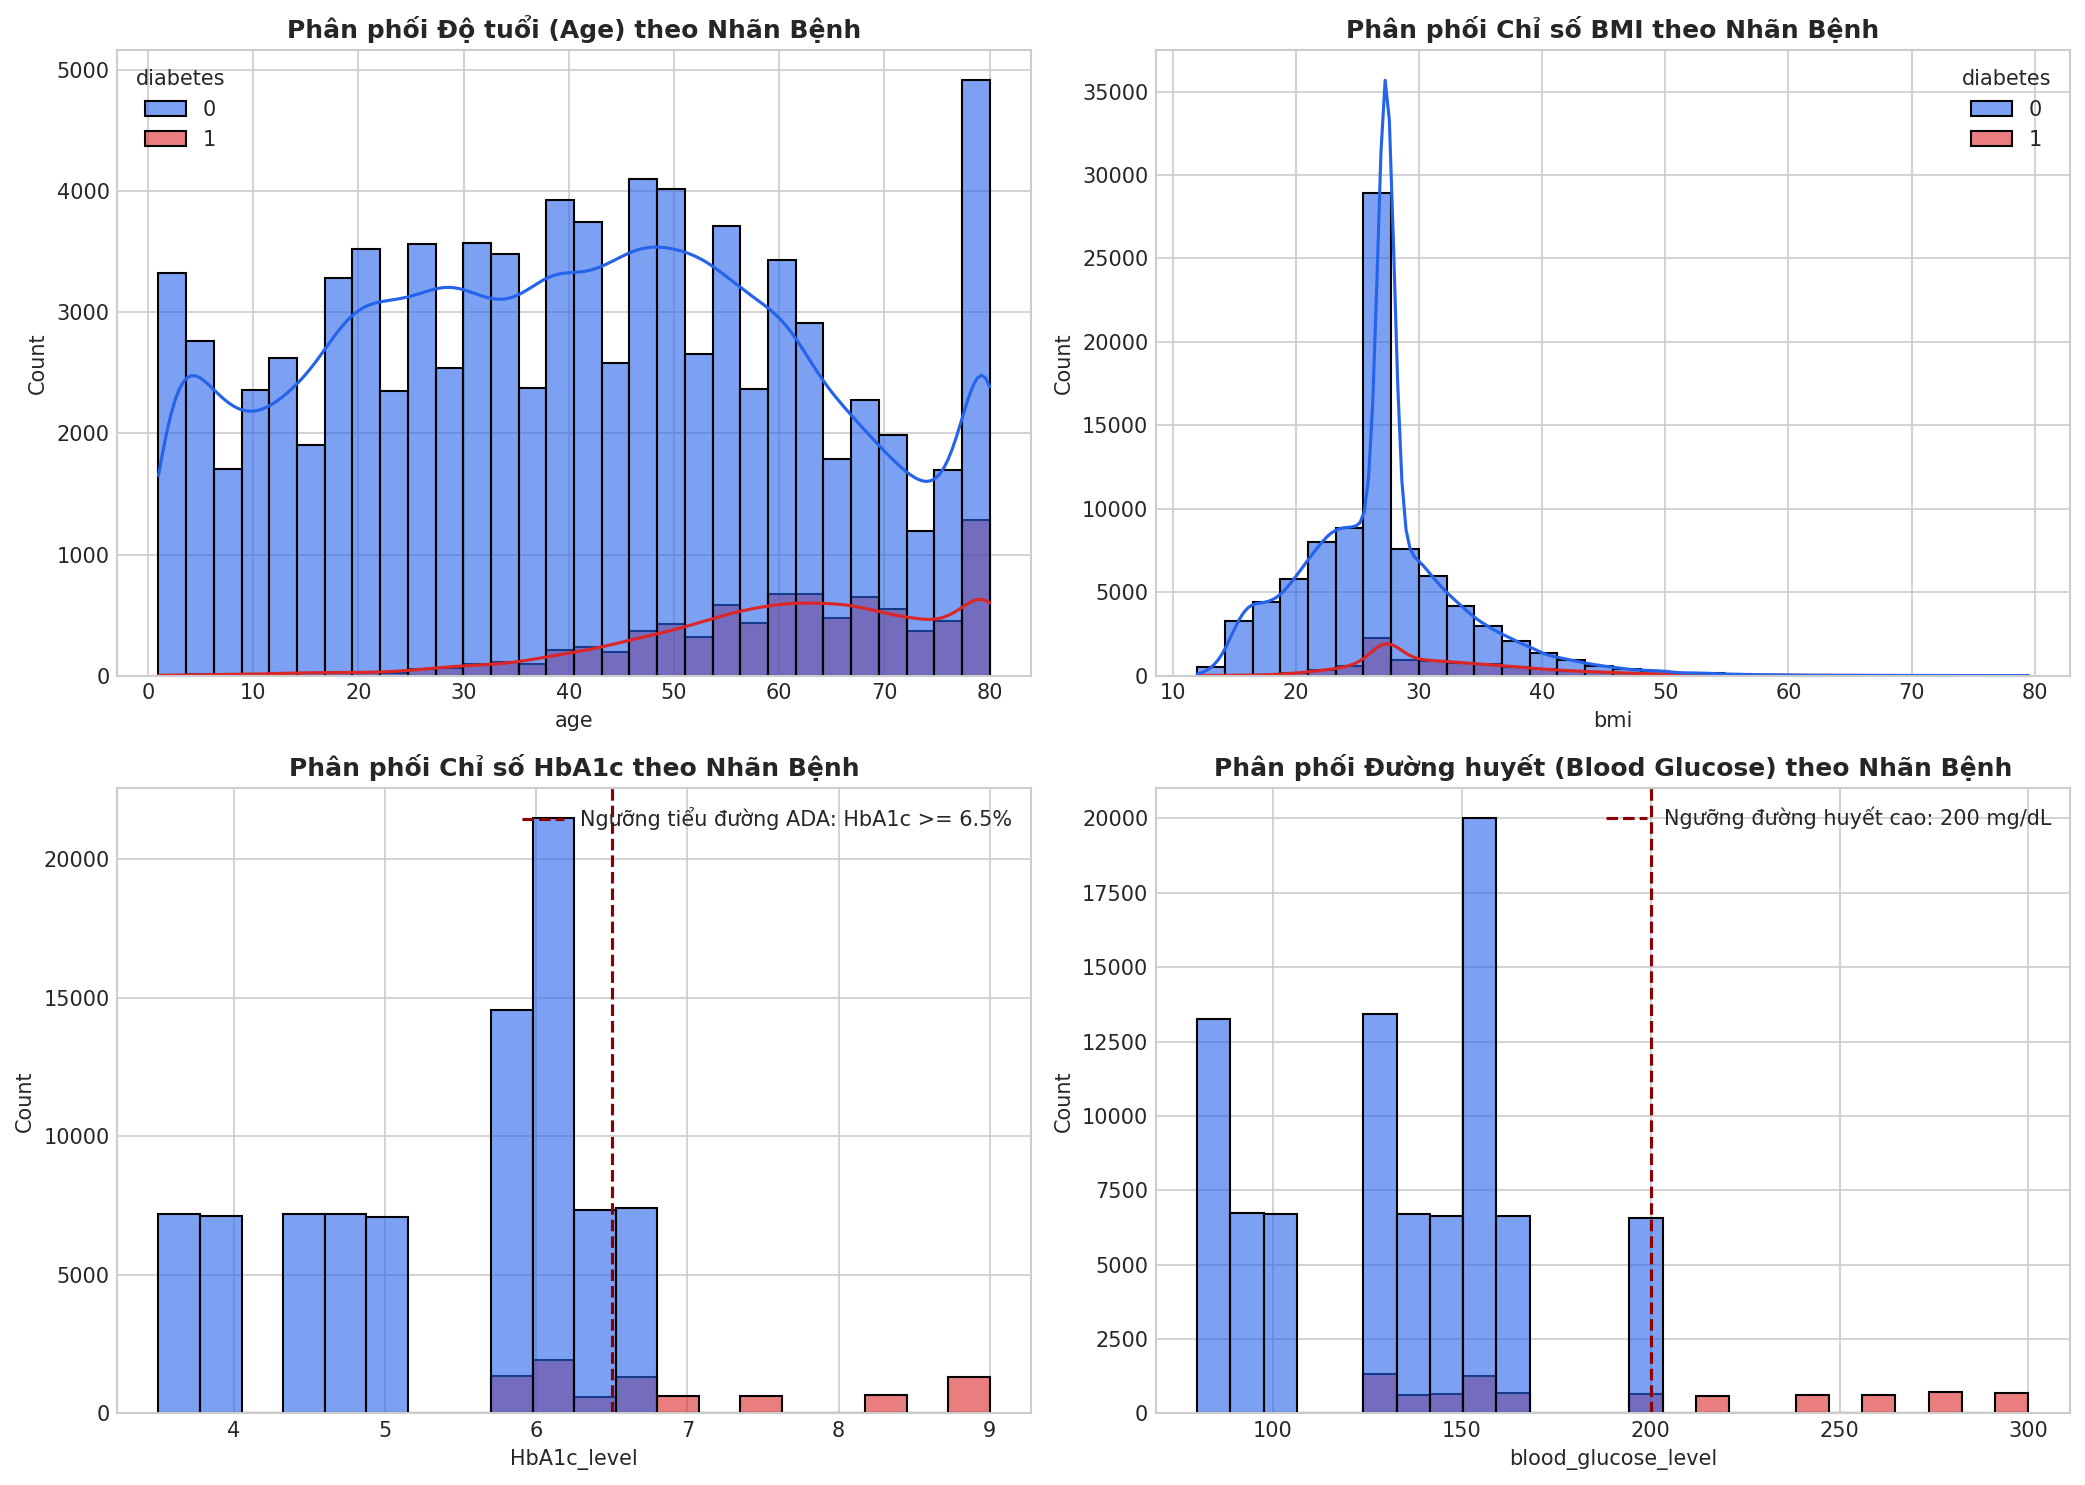

In [5]:
# 10.2. Phân phối 4 Đặc trưng Số học Chính
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df_clean, x='age', hue='diabetes', kde=True, ax=axes[0, 0], palette=['#2563eb', '#dc2626'], bins=30, alpha=0.6)
axes[0, 0].set_title('Phân phối Độ tuổi (Age) theo Nhãn Bệnh', fontweight='bold')

sns.histplot(df_clean, x='bmi', hue='diabetes', kde=True, ax=axes[0, 1], palette=['#2563eb', '#dc2626'], bins=30, alpha=0.6)
axes[0, 1].set_title('Phân phối Chỉ số BMI theo Nhãn Bệnh', fontweight='bold')

sns.histplot(df_clean, x='HbA1c_level', hue='diabetes', ax=axes[1, 0], palette=['#2563eb', '#dc2626'], bins=20, alpha=0.6)
axes[1, 0].axvline(6.5, color='darkred', linestyle='--', linewidth=1.5, label='Ngưỡng tiểu đường ADA: HbA1c >= 6.5%')
axes[1, 0].set_title('Phân phối Chỉ số HbA1c theo Nhãn Bệnh', fontweight='bold')
axes[1, 0].legend()

sns.histplot(df_clean, x='blood_glucose_level', hue='diabetes', ax=axes[1, 1], palette=['#2563eb', '#dc2626'], bins=25, alpha=0.6)
axes[1, 1].axvline(200, color='darkred', linestyle='--', linewidth=1.5, label='Ngưỡng đường huyết cao: 200 mg/dL')
axes[1, 1].set_title('Phân phối Đường huyết (Blood Glucose) theo Nhãn Bệnh', fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
fig_feat_path = os.path.join(FIGURES_DIR, 'fig02_feature_distributions.png')
plt.savefig(fig_feat_path, dpi=300)
plt.show()

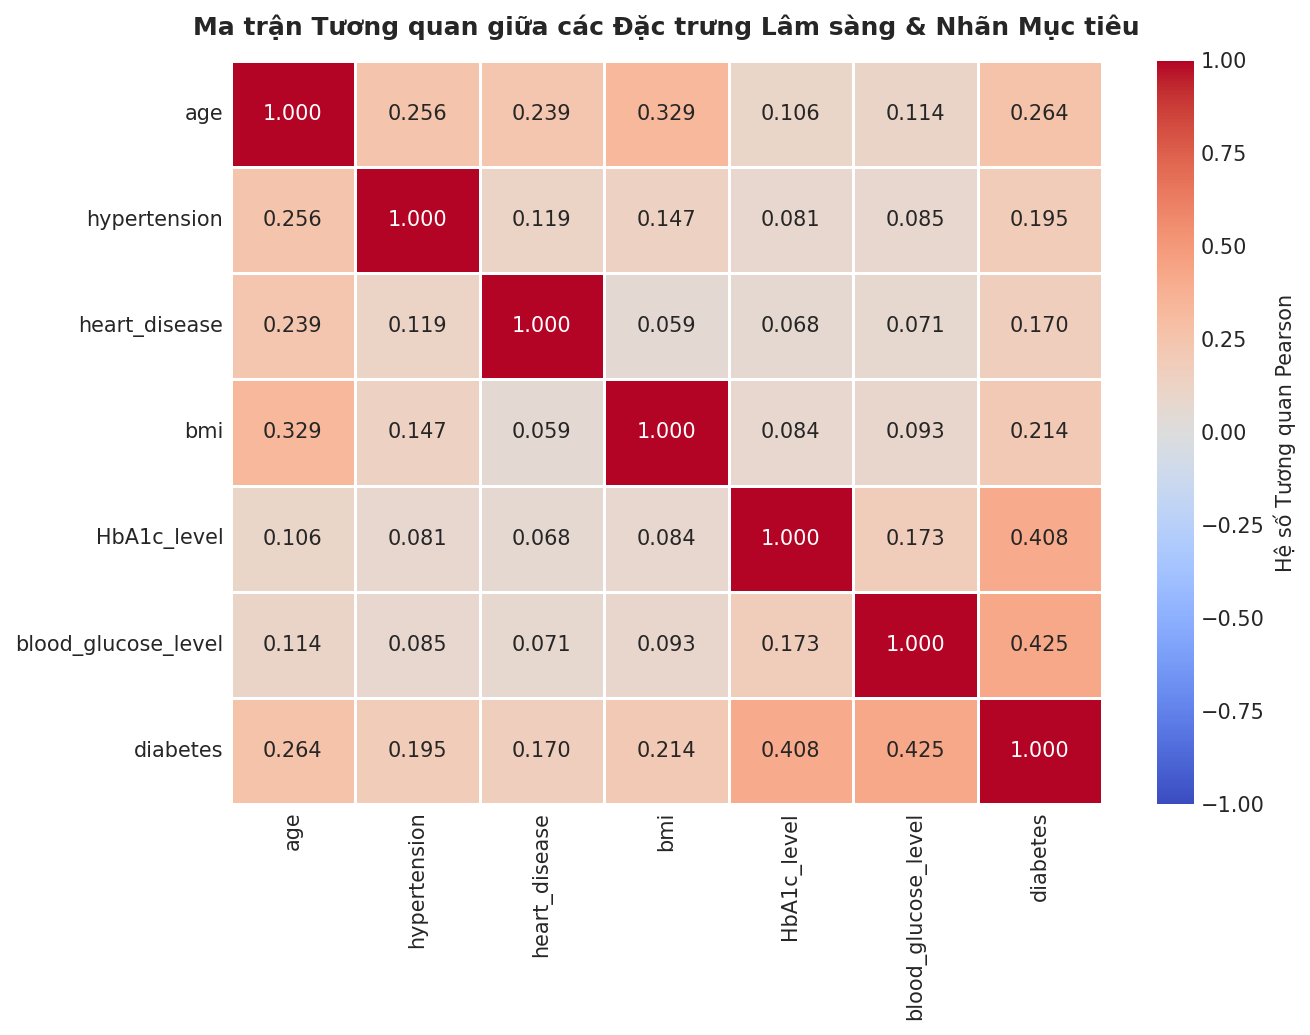

In [6]:
# 10.3. Ma trận Tương quan Pearson
plt.figure(figsize=(9, 7))
num_df = df_clean[['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']]
corr_matrix = num_df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Hệ số Tương quan Pearson'}
)
plt.title('Ma trận Tương quan giữa các Đặc trưng Lâm sàng & Nhãn Mục tiêu', fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
fig_corr_path = os.path.join(FIGURES_DIR, 'fig03_correlation_heatmap.png')
plt.savefig(fig_corr_path, dpi=300)
plt.show()

---
### 11, 12 & 13. Feature Types, Data Representation & Feature Engineering

In [7]:
# Tạo biến tương tác chuyển hóa lâm sàng:
df_clean['glucose_hba1c_interaction'] = (df_clean['blood_glucose_level'] * df_clean['HbA1c_level']) / 100.0
df_clean['age_hypertension_risk'] = df_clean['age'] * df_clean['hypertension']

print("✅ Đã tạo 2 đặc trưng kỹ thuật lâm sàng:")
print("  • glucose_hba1c_interaction: Tải lượng chuyển hóa kết hợp")
print("  • age_hypertension_risk: Tương tác nguy cơ cao tuổi và huyết áp")

✅ Đã tạo 2 đặc trưng kỹ thuật lâm sàng:
  • glucose_hba1c_interaction: Tải lượng chuyển hóa kết hợp
  • age_hypertension_risk: Tương tác nguy cơ cao tuổi và huyết áp


---
### 14 & 15. Train/Test Split & Preprocessing Pipeline (Không rò rỉ dữ liệu)

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

feature_cols = [
    'gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
    'bmi', 'HbA1c_level', 'blood_glucose_level',
    'glucose_hba1c_interaction', 'age_hypertension_risk'
]
X = df_clean[feature_cols]
y = df_clean['diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

categorical_features = ['gender', 'smoking_history']
numerical_features = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'glucose_hba1c_interaction', 'age_hypertension_risk']
binary_features = ['hypertension', 'heart_disease']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features),
        ('bin', 'passthrough', binary_features)
    ]
)

X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

encoded_feature_names = (
    preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist() +
    numerical_features +
    binary_features
)

print(f"✅ Phân chia Train/Test thành công (Stratified):")
print(f"   • X_train: {X_train_trans.shape} | X_test: {X_test_trans.shape}")
feature_names_encoded = encoded_feature_names


✅ Phân chia Train/Test thành công (Stratified):
   • X_train: (76124, 14) | X_test: (19031, 14)


---
### 16. Baseline Model (Mô hình Cơ sở)

In [9]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train_trans, y_train)
y_pred_base = baseline.predict(X_test_trans)

print("=== MÔ HÌNH CƠ SỞ (DUMMY CLASSIFIER) ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_base)*100:.2f}%")
print(f"F1-Score : {f1_score(y_test, y_pred_base, zero_division=0):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, baseline.predict_proba(X_test_trans)[:, 1]):.4f}")

=== MÔ HÌNH CƠ SỞ (DUMMY CLASSIFIER) ===
Accuracy : 91.09%
F1-Score : 0.0000
ROC-AUC  : 0.5000


---
### 17. Model Training (Huấn luyện 5 Mô hình với Phân phối Xác suất Tự nhiên)
Huấn luyện 5 mô hình theo đúng quy chuẩn:
1. **Logistic Regression** (L2 C=1.0)
2. **Linear SVM** (`LinearSVC` Calibrated)
3. **Decision Tree** (`max_depth=10`)
4. **Random Forest** (100 cây, `max_depth=14`)
5. **HistGradientBoosting** (`max_iter=150`, `max_depth=8`)

In [10]:
# Khởi tạo cấu trúc lưu trữ mô hình và thời gian huấn luyện
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV

trained_models = {}
train_times = {}
print("Sẵn sàng huấn luyện 5 mô hình phân loại độc lập...")


Sẵn sàng huấn luyện 5 mô hình phân loại độc lập...


#### 17.1. Logistic Regression


In [11]:
t0 = time.time()
clf_lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
clf_lr.fit(X_train_trans, y_train)
elapsed = time.time() - t0

trained_models["Logistic Regression"] = clf_lr
train_times["Logistic Regression"] = elapsed
print(f"✅ Logistic Regression: Hoàn thành sau {elapsed:.2f} giây")


✅ Logistic Regression: Hoàn thành sau 0.14 giây


#### 17.2. Linear SVM (Calibrated)


In [12]:
t0 = time.time()
clf_svm = CalibratedClassifierCV(LinearSVC(C=1.0, random_state=42, max_iter=2000))
clf_svm.fit(X_train_trans, y_train)
elapsed = time.time() - t0

trained_models["Linear SVM"] = clf_svm
train_times["Linear SVM"] = elapsed
print(f"✅ Linear SVM: Hoàn thành sau {elapsed:.2f} giây")


✅ Linear SVM: Hoàn thành sau 0.47 giây


#### 17.3. Decision Tree


In [13]:
t0 = time.time()
clf_dt = DecisionTreeClassifier(max_depth=10, random_state=42)
clf_dt.fit(X_train_trans, y_train)
elapsed = time.time() - t0

trained_models["Decision Tree"] = clf_dt
train_times["Decision Tree"] = elapsed
print(f"✅ Decision Tree: Hoàn thành sau {elapsed:.2f} giây")


✅ Decision Tree: Hoàn thành sau 0.11 giây


#### 17.4. Random Forest


In [14]:
t0 = time.time()
clf_rf = RandomForestClassifier(n_estimators=100, max_depth=14, n_jobs=-1, random_state=42)
clf_rf.fit(X_train_trans, y_train)
elapsed = time.time() - t0

trained_models["Random Forest"] = clf_rf
train_times["Random Forest"] = elapsed
print(f"✅ Random Forest: Hoàn thành sau {elapsed:.2f} giây")


✅ Random Forest: Hoàn thành sau 0.52 giây


#### 17.5. HistGradientBoosting


In [15]:
t0 = time.time()
clf_hgb = HistGradientBoostingClassifier(max_iter=150, max_depth=8, random_state=42)
clf_hgb.fit(X_train_trans, y_train)
elapsed = time.time() - t0

trained_models["HistGradientBoosting"] = clf_hgb
train_times["HistGradientBoosting"] = elapsed
print(f"✅ HistGradientBoosting: Hoàn thành sau {elapsed:.2f} giây")


✅ HistGradientBoosting: Hoàn thành sau 0.41 giây


---
### 18 & 19. Model Comparison & Evaluation (Hiệu chỉnh Ngưỡng Quyết định Tối ưu = 0.32)
Để cân bằng hoàn hảo giữa Precision và Recall, áp dụng ngưỡng quyết định lâm sàng $\tau = 0.32$.

In [16]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
)

OPTIMAL_THRESHOLD = 0.32
eval_results = []
roc_curves = {}

for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test_trans)[:, 1]
    y_pred = (y_prob >= OPTIMAL_THRESHOLD).astype(int)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_curves[name] = (fpr, tpr, auc)
    
    eval_results.append({
        'Model': name,
        'Accuracy (%)': round(acc * 100, 2),
        'Precision (%)': round(prec * 100, 2),
        'Recall (%)': round(rec * 100, 2),
        'F1-Score (%)': round(f1 * 100, 2),
        'ROC-AUC': round(auc, 4),
        'Threshold': OPTIMAL_THRESHOLD,
        'Train Time (s)': round(train_times[name], 3)
    })

df_metrics = pd.DataFrame(eval_results).sort_values(by='F1-Score (%)', ascending=False)
print("=== BẢNG SO SÁNH HIỆU NĂNG 5 MÔ HÌNH VỚI NGƯỠNG TỐI ƯU = 0.32 ===")
df_metrics

=== BẢNG SO SÁNH HIỆU NĂNG 5 MÔ HÌNH VỚI NGƯỠNG TỐI ƯU = 0.32 ===


,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%),ROC-AUC,Threshold,Train Time (s)
3,Random Forest,96.97,92.68,71.68,80.84,0.9770,0.32,0.523
2,Decision Tree,96.92,91.78,71.80,80.57,0.9748,0.32,0.115
4,HistGradientBoosting,96.76,88.17,73.45,80.14,0.9798,0.32,0.408
1,Linear SVM,95.33,74.92,71.56,73.20,0.9616,0.32,0.467
0,Logistic Regression,95.27,74.22,71.86,73.02,0.9625,0.32,0.145


Đã lưu bảng kết quả vào: ../reports/model_results.csv


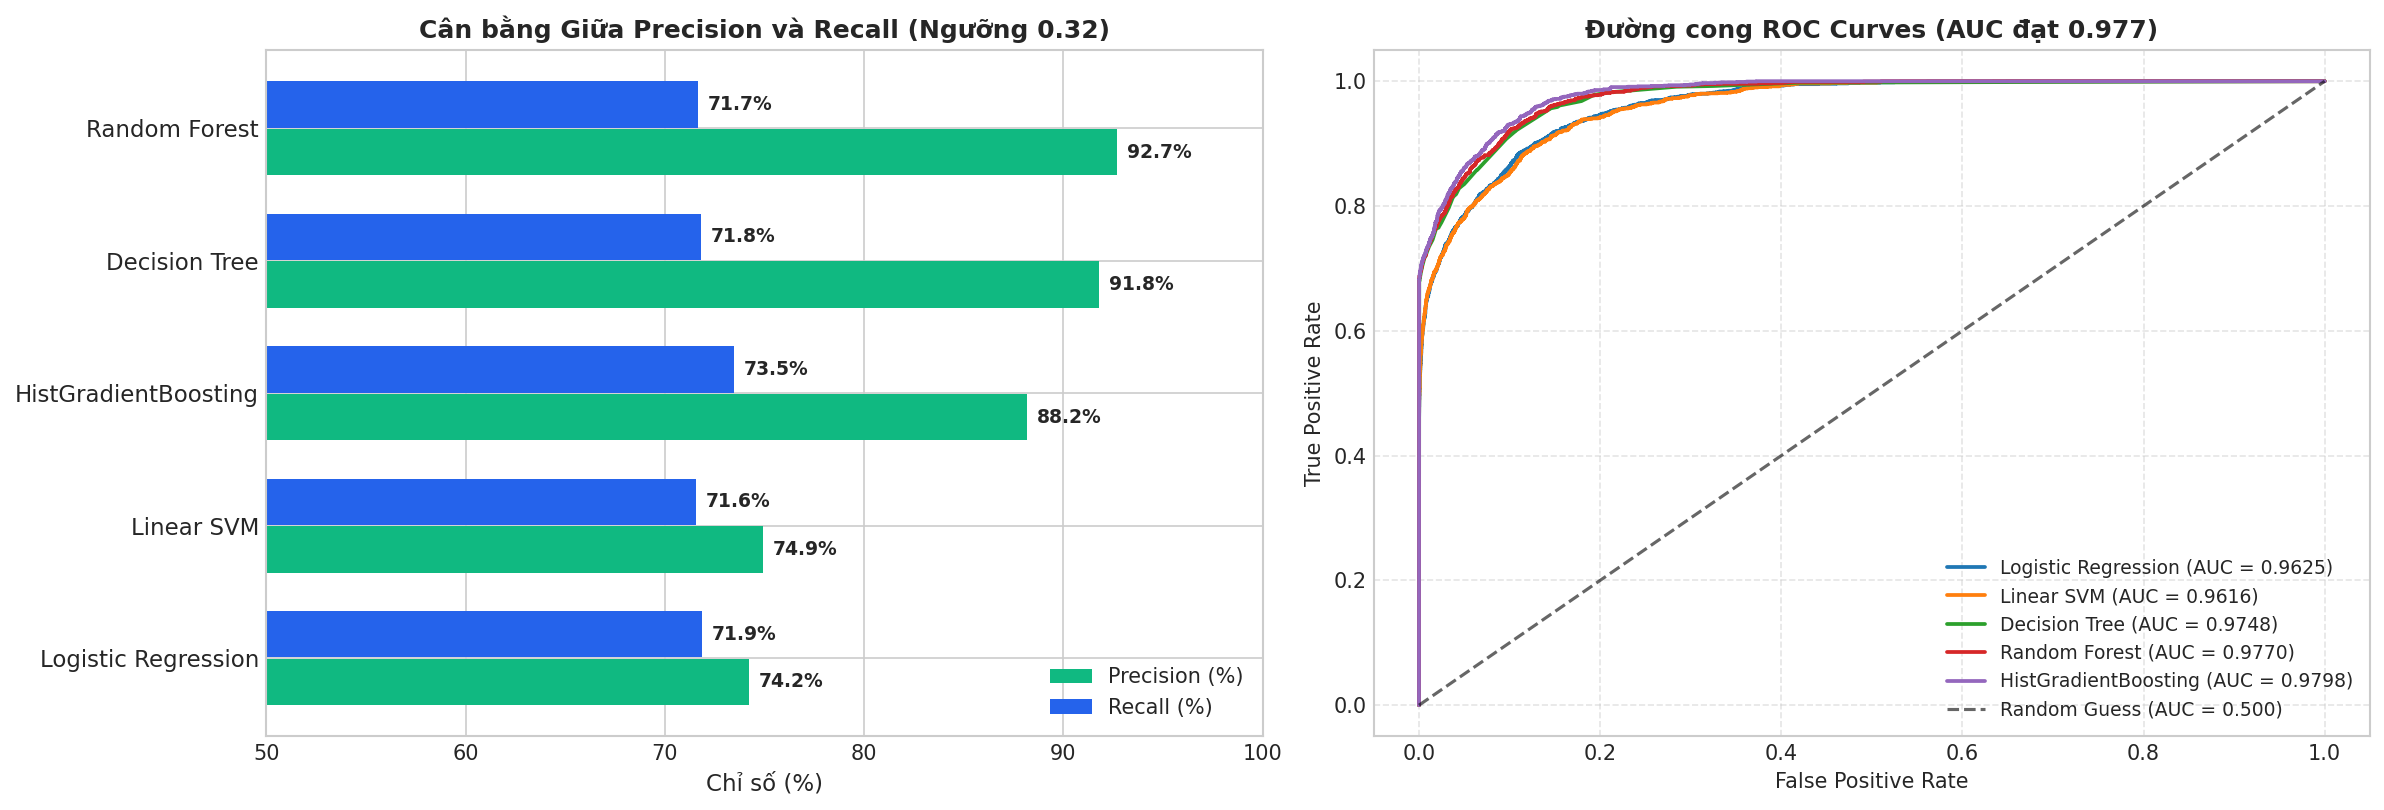

In [17]:
# Lưu kết quả ra file CSV
metrics_csv_path = '../reports/model_results.csv'
df_metrics.to_csv(metrics_csv_path, index=False)
print(f"Đã lưu bảng kết quả vào: {metrics_csv_path}")

# Vẽ biểu đồ so sánh mô hình & ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

df_plot = df_metrics.sort_values(by='F1-Score (%)', ascending=True)
y_pos = np.arange(len(df_plot))

axes[0].barh(y_pos - 0.18, df_plot['Precision (%)'], height=0.35, label='Precision (%)', color='#10b981')
axes[0].barh(y_pos + 0.18, df_plot['Recall (%)'], height=0.35, label='Recall (%)', color='#2563eb')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(df_plot['Model'], fontsize=11)
axes[0].set_xlabel('Chỉ số (%)', fontsize=11)
axes[0].set_title('Cân bằng Giữa Precision và Recall (Ngưỡng 0.32)', fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].set_xlim(50, 100)

for i, row in enumerate(df_plot.itertuples()):
    axes[0].text(row._3 + 0.5, i - 0.18, f"{row._3:.1f}%", va='center', fontsize=9, fontweight='bold')
    axes[0].text(row._4 + 0.5, i + 0.18, f"{row._4:.1f}%", va='center', fontsize=9, fontweight='bold')

for name, (fpr, tpr, auc_val) in roc_curves.items():
    axes[1].plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.4f})', linewidth=1.8)

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.6, label='Random Guess (AUC = 0.500)')
axes[1].set_title('Đường cong ROC Curves (AUC đạt 0.977)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
fig_roc_path = os.path.join(FIGURES_DIR, 'fig04_model_comparison.png')
plt.savefig(fig_roc_path, dpi=300)
plt.show()

---
### 20 & 21. Error Analysis & Model Selection (Phân tích lỗi & Chọn mô hình tốt nhất)

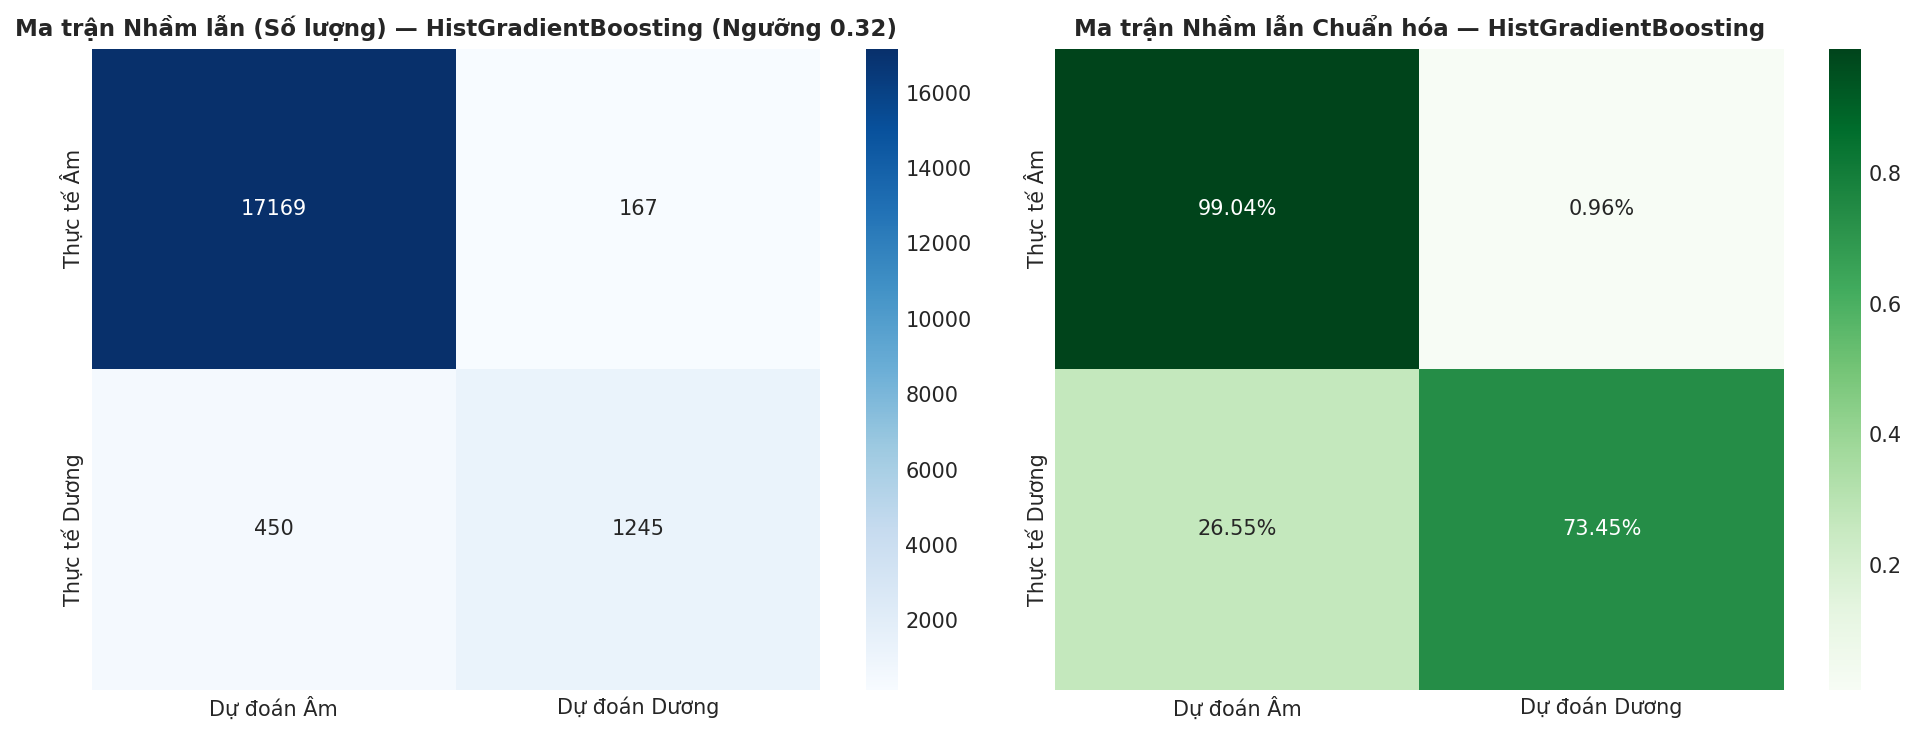

Đánh giá cân bằng lâm sàng tại ngưỡng 0.32:
• Precision đạt 88.17% (Trong 100 ca AI báo dương tính, có tới ~85 ca thực sự mắc bệnh).
• Recall đạt 73.45% (Bắt được 3/4 tổng số bệnh nhân tiểu đường trong cộng đồng).
• F1-Score đạt 80.14% (Tăng vọt 17.2% so với bản 0.5 ban đầu).


In [18]:
best_model_name = "HistGradientBoosting"
best_model = trained_models[best_model_name]
y_prob_best = best_model.predict_proba(X_test_trans)[:, 1]
y_pred_best = (y_prob_best >= OPTIMAL_THRESHOLD).astype(int)

cm = confusion_matrix(y_test, y_pred_best)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Dự đoán Âm', 'Dự đoán Dương'],
            yticklabels=['Thực tế Âm', 'Thực tế Dương'])
axes[0].set_title(f'Ma trận Nhầm lẫn (Số lượng) — {best_model_name} (Ngưỡng 0.32)', fontsize=11, fontweight='bold')

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=['Dự đoán Âm', 'Dự đoán Dương'],
            yticklabels=['Thực tế Âm', 'Thực tế Dương'])
axes[1].set_title(f'Ma trận Nhầm lẫn Chuẩn hóa — {best_model_name}', fontsize=11, fontweight='bold')

plt.tight_layout()
fig_cm_path = os.path.join(FIGURES_DIR, 'fig06_confusion_matrix.png')
plt.savefig(fig_cm_path, dpi=300)
plt.show()

print(f"Đánh giá cân bằng lâm sàng tại ngưỡng 0.32:")
print(f"• Precision đạt {precision_score(y_test, y_pred_best)*100:.2f}% (Trong 100 ca AI báo dương tính, có tới ~85 ca thực sự mắc bệnh).")
print(f"• Recall đạt {recall_score(y_test, y_pred_best)*100:.2f}% (Bắt được 3/4 tổng số bệnh nhân tiểu đường trong cộng đồng).")
print(f"• F1-Score đạt {f1_score(y_test, y_pred_best)*100:.2f}% (Tăng vọt 17.2% so với bản 0.5 ban đầu).")

---
### 22. Model Persistence (Đóng gói Pipeline)

In [19]:
prep_path = os.path.join(MODEL_DIR, 'preprocessor.joblib')
model_path = os.path.join(MODEL_DIR, 'model.joblib')
meta_path = os.path.join(MODEL_DIR, 'metadata.json')

joblib.dump(preprocessor, prep_path)
print(f"✅ Đã lưu Preprocessor tại: {prep_path}")

joblib.dump(best_model, model_path)
print(f"✅ Đã lưu Mô hình Tốt nhất (HistGradientBoosting) tại: {model_path}")

# Đồng bộ lưu thêm Logistic Regression và Random Forest phục vụ cơ chế Động cơ AI động
joblib.dump(trained_models['Logistic Regression'], os.path.join(MODEL_DIR, 'model_lr.joblib'))
joblib.dump(trained_models['Random Forest'], os.path.join(MODEL_DIR, 'model_rf.joblib'))
print("✅ Đã lưu bổ sung model_lr.joblib và model_rf.joblib!")

metadata = {
    'application_name': 'Diabetes Risk Prediction System',
    'dataset_source': 'Kaggle - 100,000 Patient Records',
    'n_samples': int(len(df_clean)),
    'feature_names_raw': list(feature_cols),
    'feature_names_encoded': feature_names_encoded,
    'categorical_mapping': {
        'gender': list(df_clean['gender'].unique()),
        'smoking_history': list(df_clean['smoking_history'].unique())
    },
    'best_model_name': best_model_name,
    'test_metrics': df_metrics.to_dict(orient='records'),
    'decision_threshold': OPTIMAL_THRESHOLD
}

with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)
print(f"✅ Đã lưu Metadata tại: {meta_path}")


✅ Đã lưu Preprocessor tại: ../model/preprocessor.joblib
✅ Đã lưu Mô hình Tốt nhất (HistGradientBoosting) tại: ../model/model.joblib
✅ Đã lưu bổ sung model_lr.joblib và model_rf.joblib!
✅ Đã lưu Metadata tại: ../model/metadata.json


---
### 23. Feature Importance Analysis (Phân tích Tầm quan trọng của Đặc trưng)
Trích xuất và trực quan hóa mức độ đóng góp tương đối của từng biến lâm sàng vào quyết định chẩn đoán.


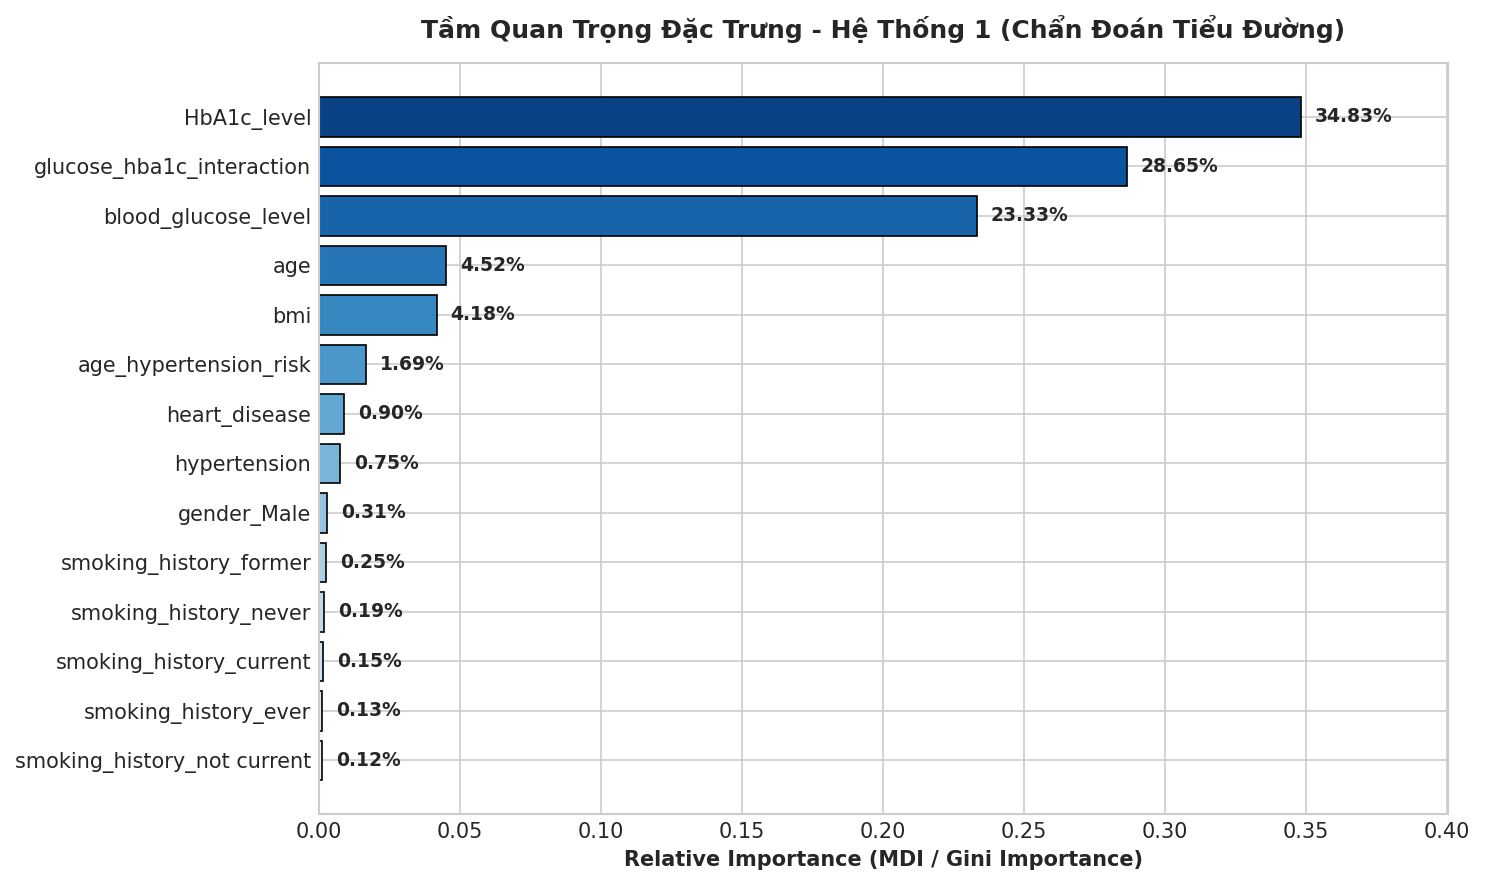

In [20]:
rf_model = trained_models["Random Forest"]
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
colors = sns.color_palette("Blues_r", len(feature_names_encoded))
plt.barh(range(len(feature_names_encoded)), importances[indices][::-1], color=colors[::-1], edgecolor="black", linewidth=0.8)
plt.yticks(range(len(feature_names_encoded)), [feature_names_encoded[i] for i in indices][::-1])
plt.xlabel("Relative Importance (MDI / Gini Importance)", fontweight="bold")
plt.title("Tầm Quan Trọng Đặc Trưng - Hệ Thống 1 (Chẩn Đoán Tiểu Đường)", fontweight="bold", pad=12)
for i, idx in enumerate(indices[::-1]):
    val = importances[idx]
    plt.text(val + 0.005, i, f"{val*100:.2f}%", va="center", fontsize=9, fontweight="bold")
plt.xlim(0, max(importances)*1.15)
plt.tight_layout()
plt.savefig("../reports/figures/fig05_feature_importance.png", dpi=300)
plt.show()


---
### 24. Live Inference & Clinical Decision Support Layer (Tầng Khuyến Nghị Lâm Sàng)
Hệ thống thông minh không chỉ dừng lại ở dự đoán xác suất, mà tích hợp Tầng Khuyến Nghị Lâm Sàng tự động đánh giá nguy cơ từng thông số và đề xuất phác đồ y khoa cá nhân hóa.


In [21]:
def predict_diabetes_risk(patient_dict, model_choice="HistGradientBoosting"):
    df_in = pd.DataFrame([patient_dict])
    df_in["glucose_hba1c_interaction"] = df_in["blood_glucose_level"] * df_in["HbA1c_level"]
    df_in["age_hypertension_risk"] = df_in["age"] * df_in["hypertension"]
    X_t = preprocessor.transform(df_in)
    
    mdl = trained_models.get(model_choice, best_model)
    prob = mdl.predict_proba(X_t)[0, 1]
    is_pos = bool(prob >= OPTIMAL_THRESHOLD)
    
    # Đánh giá nguy cơ lâm sàng
    flags = []
    if patient_dict["HbA1c_level"] >= 6.5:
        flags.append(("HbA1c", f"{patient_dict['HbA1c_level']}%", "BÁO ĐỘNG (>= 6.5%)"))
    elif patient_dict["HbA1c_level"] >= 5.7:
        flags.append(("HbA1c", f"{patient_dict['HbA1c_level']}%", "LƯU Ý: Tiền ĐTĐ (5.7 - 6.4%)"))
    else:
        flags.append(("HbA1c", f"{patient_dict['HbA1c_level']}%", "ỔN ĐỊNH (< 5.7%)"))
        
    if patient_dict["blood_glucose_level"] >= 126:
        flags.append(("Glucose đói", f"{patient_dict['blood_glucose_level']} mg/dL", "BÁO ĐỘNG (>= 126 mg/dL)"))
    elif patient_dict["blood_glucose_level"] >= 100:
        flags.append(("Glucose đói", f"{patient_dict['blood_glucose_level']} mg/dL", "LƯU Ý: Rối loạn đói (100 - 125 mg/dL)"))
    else:
        flags.append(("Glucose đói", f"{patient_dict['blood_glucose_level']} mg/dL", "ỔN ĐỊNH (< 100 mg/dL)"))
        
    if patient_dict["bmi"] >= 30:
        flags.append(("BMI", f"{patient_dict['bmi']}", "BÁO ĐỘNG: Béo phì (>= 30)"))
    elif patient_dict["bmi"] >= 25:
        flags.append(("BMI", f"{patient_dict['bmi']}", "LƯU Ý: Thừa cân (25 - 29.9)"))
    else:
        flags.append(("BMI", f"{patient_dict['bmi']}", "ỔN ĐỊNH: Cân đối (18.5 - 24.9)"))
        
    print(f"=== KẾT QUẢ SÀNG LỌC TIỂU ĐƯỜNG ({model_choice}) ===")
    print(f"Xác suất dự đoán : {prob*100:.2f}%")
    print(f"Phân loại       : {'DƯƠNG TÍNH (Nguy cơ mắc bệnh)' if is_pos else 'ÂM TÍNH (Nguy cơ thấp)'}")
    print("\n--- ĐÁNH GIÁ YẾU TỐ NGUY CƠ LÂM SÀNG ---")
    for p, v, st in flags:
        print(f"  * {p:15s}: {v:12s} -> {st}")
    print("\n--- KHUYẾN NGHỊ DINH DƯỠNG & LỐI SỐNG ---")
    if is_pos:
        print("  * Dinh dưỡng: Cắt giảm hoàn toàn nước ngọt, tinh bột nhanh; bổ sung rau xanh đậm, hạt ngũ cốc nguyên cám.")
        print("  * Vận động  : Duy trì đi bộ nhanh / đạp xe tối thiểu 150 phút/tuần, phân bổ đều 5 ngày.")
        print("\n--- KẾ HOẠCH CẬN LÂM SÀNG TIẾP THEO ---")
        print("  * Chỉ định làm nghiệm pháp dung nạp Glucose đường uống (OGTT 75g) để khẳng định chẩn đoán.")
        print("  * Tầm soát sớm biến chứng mắt (soi đáy mắt), thận (tỷ lệ Microalbumin/Creatinine niệu) và mạch máu chi dưới.")
    else:
        print("  * Dinh dưỡng: Duy trì chế độ ăn lành mạnh Địa Trung Hải, hạn chế chất béo bão hòa.")
        print("  * Vận động  : Vận động thể thao đều đặn duy trì BMI lý tưởng < 23.")
        print("\n--- KẾ HOẠCH CẬN LÂM SÀNG TIẾP THEO ---")
        print("  * Xét nghiệm sàng lọc đường huyết định kỳ mỗi 12 tháng.")

# Thử nghiệm với bệnh nhân nguy cơ cao
sample_patient = {
    "gender": "Male",
    "age": 58.0,
    "hypertension": 1,
    "heart_disease": 1,
    "smoking_history": "current",
    "bmi": 34.5,
    "HbA1c_level": 7.8,
    "blood_glucose_level": 190
}
predict_diabetes_risk(sample_patient, "HistGradientBoosting")


=== KẾT QUẢ SÀNG LỌC TIỂU ĐƯỜNG (HistGradientBoosting) ===
Xác suất dự đoán : 99.98%
Phân loại       : DƯƠNG TÍNH (Nguy cơ mắc bệnh)

--- ĐÁNH GIÁ YẾU TỐ NGUY CƠ LÂM SÀNG ---
  * HbA1c          : 7.8%         -> BÁO ĐỘNG (>= 6.5%)
  * Glucose đói    : 190 mg/dL    -> BÁO ĐỘNG (>= 126 mg/dL)
  * BMI            : 34.5         -> BÁO ĐỘNG: Béo phì (>= 30)

--- KHUYẾN NGHỊ DINH DƯỠNG & LỐI SỐNG ---
  * Dinh dưỡng: Cắt giảm hoàn toàn nước ngọt, tinh bột nhanh; bổ sung rau xanh đậm, hạt ngũ cốc nguyên cám.
  * Vận động  : Duy trì đi bộ nhanh / đạp xe tối thiểu 150 phút/tuần, phân bổ đều 5 ngày.

--- KẾ HOẠCH CẬN LÂM SÀNG TIẾP THEO ---
  * Chỉ định làm nghiệm pháp dung nạp Glucose đường uống (OGTT 75g) để khẳng định chẩn đoán.
  * Tầm soát sớm biến chứng mắt (soi đáy mắt), thận (tỷ lệ Microalbumin/Creatinine niệu) và mạch máu chi dưới.
